# [Improved V5] NFL Draft Prediction

Strategy: V3 features + Optuna hyperparameter tuning

Features (same as V3 — leak-free):
- Base numeric + categoricals
- BMI, missing flags, n_missing
- Position-relative z-scores
- Speed score
- Age z-score by position
- Interaction features: Height x Weight, Sprint x Vertical, Sprint x Broad_Jump

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\YSS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the Data

In [2]:
train = pd.read_csv('input/train.csv')
test  = pd.read_csv('input/test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)

Train shape: (2781, 16)
Test shape:  (696, 15)


## 3. Feature Engineering (V3 features — leak-free)

In [3]:
perf_cols = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
             'Broad_Jump', 'Agility_3cone', 'Shuttle']

def engineer_features(df):
    df = df.copy()

    # BMI
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

    # Missing-value flags
    for col in perf_cols:
        df[f'{col}_missing'] = df[col].isna().astype(int)
    df['n_missing'] = df[perf_cols].isna().sum(axis=1)

    # Position-relative z-scores
    for col in perf_cols:
        grp = df.groupby('Position')[col]
        df[f'{col}_pos_zscore'] = (df[col] - grp.transform('mean')) / (grp.transform('std') + 1e-6)

    # Speed score
    sprint_inv  = 1.0 / (df['Sprint_40yd']  + 1e-6)
    shuttle_inv = 1.0 / (df['Shuttle']       + 1e-6)
    agility_inv = 1.0 / (df['Agility_3cone'] + 1e-6)
    df['speed_score'] = sprint_inv + shuttle_inv + agility_inv

    # Age relative to position (z-score)
    age_grp = df.groupby('Position')['Age']
    df['age_pos_zscore'] = (df['Age'] - age_grp.transform('mean')) / (age_grp.transform('std') + 1e-6)

    # Interaction features
    df['height_x_weight']   = df['Height'] * df['Weight']
    df['sprint_x_vertical'] = df['Sprint_40yd'] * df['Vertical_Jump']
    df['sprint_x_broad']    = df['Sprint_40yd'] * df['Broad_Jump']

    return df

train = engineer_features(train)
test  = engineer_features(test)
print('Feature engineering done. Train shape:', train.shape)

Feature engineering done. Train shape: (2781, 35)


## 4. Preprocessing

In [4]:
cat_cols = ['Player_Type', 'Position_Type', 'Position']
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

base_num = ['Year', 'Age', 'Height', 'Weight',
            'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
            'Broad_Jump', 'Agility_3cone', 'Shuttle']

engineered = (
    ['BMI', 'n_missing'] +
    [f'{c}_missing'    for c in perf_cols] +
    [f'{c}_pos_zscore' for c in perf_cols] +
    ['speed_score', 'age_pos_zscore',
     'height_x_weight', 'sprint_x_vertical', 'sprint_x_broad']
)

features = base_num + cat_cols + engineered

X      = train[features]
y      = train['Drafted']
X_test = test[features]

print(f'Total features: {len(features)}')

Total features: 32


## 5. Hyperparameter Tuning with Optuna

In [5]:
def objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'verbose':           -1,
        'n_jobs':            -1,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(X))

    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        model = lgb.train(
            params, dtrain,
            num_boost_round=1000,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)],
        )
        oof[val_idx] = model.predict(X_val)

    return roc_auc_score(y, oof)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest OOF AUC: {study.best_value:.5f}')
print('Best params:', study.best_params)

Best trial: 24. Best value: 0.831642: 100%|██████████| 50/50 [01:17<00:00,  1.56s/it]


Best OOF AUC: 0.83164
Best params: {'learning_rate': 0.03478142220462752, 'num_leaves': 141, 'min_child_samples': 32, 'feature_fraction': 0.9452378063794971, 'bagging_fraction': 0.627962555601359, 'bagging_freq': 7, 'lambda_l1': 9.184224027972787, 'lambda_l2': 1.3245961285905348e-06}


## 6. Train Final Model with Best Params

In [6]:
best_params = {
    'objective':  'binary',
    'metric':     'auc',
    'verbose':    -1,
    'n_jobs':     -1,
    **study.best_params
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        best_params, dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)],
    )

    oof_preds[val_idx] = model.predict(X_val)
    test_preds        += model.predict(X_test) / 5

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f'Fold {fold+1}  AUC: {fold_auc:.5f}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\nOverall OOF AUC: {oof_auc:.5f}')

Fold 1  AUC: 0.79523
Fold 2  AUC: 0.86898
Fold 3  AUC: 0.87383
Fold 4  AUC: 0.78976
Fold 5  AUC: 0.83736

Overall OOF AUC: 0.83164


## 7. Feature Importance

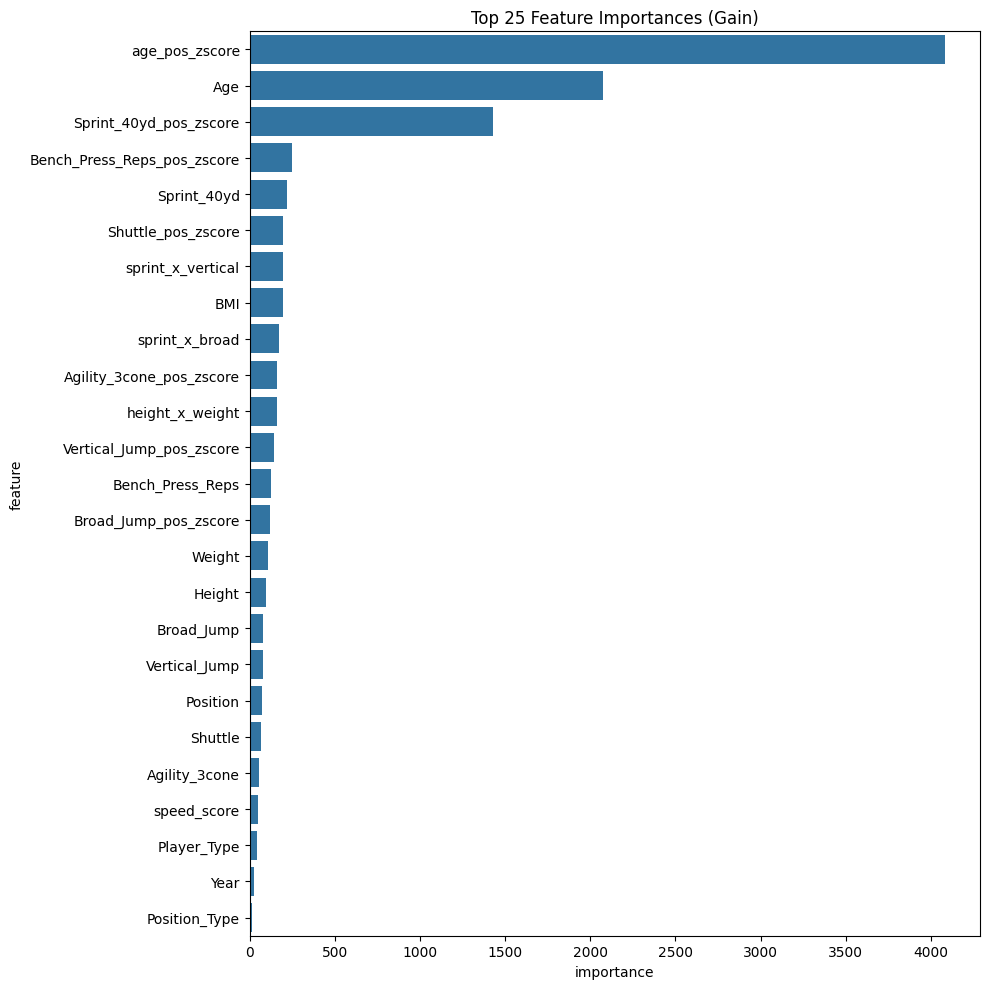

                        feature   importance
28               age_pos_zscore  4084.026281
1                           Age  2073.985101
21       Sprint_40yd_pos_zscore  1429.088645
23  Bench_Press_Reps_pos_zscore   252.236330
4                   Sprint_40yd   218.191135
26           Shuttle_pos_zscore   196.480477
30            sprint_x_vertical   194.729614
13                          BMI   193.628254
31               sprint_x_broad   174.141141
25     Agility_3cone_pos_zscore   163.561368
29              height_x_weight   159.444659
22     Vertical_Jump_pos_zscore   146.478301
6              Bench_Press_Reps   127.136873
24        Broad_Jump_pos_zscore   121.484269
3                        Weight   108.709469
2                        Height    97.342361
7                    Broad_Jump    81.659984
5                 Vertical_Jump    78.379367
12                     Position    76.072968
9                       Shuttle    67.830926


In [7]:
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(data=importance.head(25), x='importance', y='feature')
plt.title('Top 25 Feature Importances (Gain)')
plt.tight_layout()
plt.show()

print(importance.head(20).to_string())

## 8. Create the Submission File

In [8]:
submission = pd.read_csv('input/sample_submission.csv')
submission['Drafted'] = test_preds
submission.to_csv('submission_V5.csv', index=False)
print('submission_V5.csv saved!')
submission.head()

submission_V5.csv saved!


,Id,Drafted
0,2781,0.698142
1,2782,0.804208
2,2783,0.861275
3,2784,0.912827
4,2785,0.696699
